**Berikut merupakan notebook untuk Proses Fine-Tuning BERT
Informasi lebih detail mengenai BERT dapat dilihat kembali pada halaman notion lewat link berikut**: https://tsukishimaalan20.notion.site/NLP-AOL-Language-based-Scheduler-b0a63589a4b84187b8316cf0450d2c9c?pvs=4

## import Library


Berikut adalah library yang kami gunakan untuk melakukan klasifikasi mulai dari tahap preprocess hingga evaluation.

In [ ]:
import optuna
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

c:\Users\user\anaconda3\envs\deep_learning_pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preprocess Data

In [ ]:
# Load 10000 sample data dari dataset
dataset = pd.read_csv('./train.csv').sample(10000)
# dataset = pd.read_csv('/content/YahooTopic_test.csv').sample(10000)

In [ ]:
# tampilan berikut menunjukkan belum adanya penamaan kolom dalam dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 326599 to 1260342
Data columns (total 4 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 Non-Null Count  Dtype 
---  ------                            

In [ ]:
# Dikarenakan tidak ada penamaan kolom dalam dataset, untuk mempermudah pengolahan data,
# setiap kolom dinamai sebagai berikut
dataset.columns = ['label', 'title', 'content', 'answer']
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 326599 to 1260342
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    10000 non-null  int64 
 1   title    10000 non-null  object
 2   content  5560 non-null   object
 3   answer   9835 non-null   object
dtypes: int64(1), object(3)
memory usage: 390.6+ KB


In [ ]:
# Mengganti data kalimat yang NULL dengan spasi
# dataset = dataset.fillna(" ")
dataset = dataset.dropna()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5455 entries, 326599 to 1260342
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5455 non-null   int64 
 1   title    5455 non-null   object
 2   content  5455 non-null   object
 3   answer   5455 non-null   object
dtypes: int64(1), object(3)
memory usage: 213.1+ KB


In [ ]:
# Kolom 'title', 'content' dan 'answer' disatukan dengan spasi sebagai sebuah input
# untuk melatih model memprediksi class topik
dataset['combined'] = dataset['title'] + " " + dataset['content'] + " " + dataset['answer']

In [ ]:
# setelah ketiga kolom tadi disatukan sebagai kolom baru,
# ketiga kolom tersebut didrop
dataset = dataset.drop(columns=["title", "content", "answer"])
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5455 entries, 326599 to 1260342
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     5455 non-null   int64 
 1   combined  5455 non-null   object
dtypes: int64(1), object(1)
memory usage: 127.9+ KB


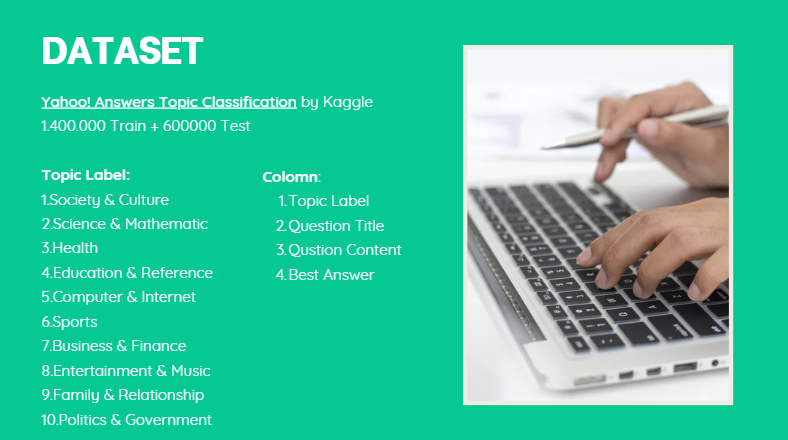

In [ ]:
# Perlu diingat bahwa label masih merupakan int64
# Jumlah kelas diperkecil dari 10 menjadi 5
dataset['label'] = dataset['label'].replace({
    9: 1,
    4: 2,
    6: 3,
    8: 5,
    7: 4,
    10: 4
})

In [ ]:
# mengubah label dari bentuk int64 ke dalam object
dataset['label'] = dataset['label'].astype(object)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5455 entries, 326599 to 1260342
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     5455 non-null   object
 1   combined  5455 non-null   object
dtypes: object(2)
memory usage: 127.9+ KB


In [ ]:
# Fungsi untuk mengganti label dari nomor menjadi namaLabel
def naming(num):
  if num == 1: return 'social'
  elif num == 2: return 'education'
  elif num == 3: return 'health'
  elif num == 4: return 'career'
  else: return 'hobby'

In [ ]:
# Mengganti kolom label dengan label yang telah dinamai
named = []
for data in dataset['label']:
  named.append(naming(data))
dataset['label'] = named

In [ ]:
# Label sudah tidak memakai angka, tetapi nama label
dataset.describe()

,label,combined
count,5455,5455
unique,5,5455
top,social,what does it mean if my leg feels like its cir...
freq,1241,1


In [ ]:
# Menampilkan tidak ada data yg duplikat
dataset.duplicated().sum()

0

In [ ]:
# Shuffle the dataset
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

## Dive into BERT

In [ ]:
# Inisialisasi BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize dataset 'combined' yang menjadi input
tokenized = dataset['combined'].apply((lambda x: tokenizer.encode_plus(x, add_special_tokens=True, max_length=128, padding='max_length', truncation=True)))
tokenized = tokenized.tolist()

BERT merupakan suatu pre-trained model yang dikembangkan oleh Google dengan
 berbasis pada transformer yang secara khusus dibuat untuk ranah NLP. Di samping
 serangkaian layer encoding Transformer nya yang membuatnya mampu menghasilkan
 word embedding secara bidirectional, model ini didasar pada proses self attention
 mechanism yang mampu memberi bobot secara khusus pada suatu kata dalam konteks
 keseluruhan teks.

In [ ]:
# Seperti diuraikan di atas,
# Melatih BERT membutuhkan dua jenis input: Vector Input (Input_ids) serta Attention Mas (attention_masks)
# Hal ini membuat proses training dapat berjalan lebih efektif
# Extract input_ids and attention_masks
input_ids = [tokenized[i]['input_ids'] for i in range(len(tokenized))]
attention_masks = [tokenized[i]['attention_mask'] for i in range(len(tokenized))]

In [ ]:
# Encode the labels data supaya dapat diproses dalam training
topic_labels = dataset['label'].astype('category').cat.codes.values.astype('long')
topic_labels

array([4, 0, 4, ..., 0, 4, 0])

In [ ]:
# Pertama-tama, split dataset menjadi training+validation set and test set
train_val_inputs, test_inputs, train_val_masks, test_masks, train_val_labels, test_labels = train_test_split(
    input_ids, attention_masks, topic_labels, random_state=42, test_size=0.2
)

# Lalu, split training+validation set menjadi training set and validation set
train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    train_val_inputs, train_val_masks, train_val_labels, random_state=42, test_size=0.25
)

In [ ]:
# Convert pecahan2 dataset ke dalam bentuk tensor
train_inputs = torch.tensor(train_inputs).cuda()
val_inputs = torch.tensor(val_inputs).cuda()
train_masks = torch.tensor(train_masks).cuda()
val_masks = torch.tensor(val_masks).cuda()
train_labels = torch.tensor(train_labels).cuda()
val_labels = torch.tensor(val_labels).cuda()
test_inputs = torch.tensor(test_inputs).cuda()
test_masks = torch.tensor(test_masks).cuda()
test_labels = torch.tensor(test_labels).cuda()

In [ ]:
# Define batch size
batch_size = 64

# Create TensorDatasets dan DataLoader dengan menyatukan kembali komponen2 inputs, mask, label dalam satu tempat
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
# Load pre-trained BERT model untuk sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=dataset['label'].nunique())

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Memindahkan model sesuai device yang tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

Code dibawah ini membuat sekaligus melakukan training model BERT itu sendiri.

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from transformers import AdamW, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
from tqdm import tqdm
import optuna

# Inisialisasi model dan list untuk tracking metrics
model0 = model
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Hyperparameter optimization function
def objective(trial):
    # Hyperparameters untuk tuning
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-6, 1e-4)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    # dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    num_epochs = 50 # Banyaknya epoch maximum untuk training
    patience = 3 # Early stopping patience maximum untuk berhenti

    model = model0 # Copy initial model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # memilih preferensi device yang tersedia
    model = torch.nn.DataParallel(model).to(device) # Memakai DataParallel untuk multi-GPU training + pindahkan model sesuai preferensi device

    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay) # inisialisasi optimizer dengan learning rate dan weight decay
    num_training_steps = num_epochs * len(train_dataloader) # menghitung jumlah langkah training yang diperlukan
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps) # inisialisasi scheduler untuk learning rate warmup

    best_val_loss = float('inf') # inisialisasi variabel untuk tracking best validation loss -> set awal max = infinity
    early_stop_count = 0 # inisialisasi variabel untuk tracking jumlah epoch tidak ada improvement -> set awal 0

    for epoch in range(num_epochs): # Looping untuk setiap epoch
        model.train() # Set model ke mode training
        total_loss = 0 # inisialisasi variabel untuk tracking total loss setiap epoch
        all_preds = [] # List untuk store preidiction
        all_labels = [] # List untuk store true labels

        for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epochs}'): # Looping untuk setiap batch
            optimizer.zero_grad() # Reset gradient
            batch = tuple(t.to(device) for t in batch) # Move batch ke device preferensi
            input_ids, attention_mask, labels = batch # Assign batch ke variabel data

            outputs = model(input_ids, attention_mask=attention_mask) # Call model.forward untuk dapatkan output
            logits = outputs.logits.float() # Ambil bentuk logits dari prediksi dan casting ke Float data type

            loss = F.cross_entropy(logits, labels.long()) # Hitung loss menggunakan cross entropy
            total_loss += loss.item() # Tambahkan akumulasi loss ke total loss

            preds = torch.argmax(logits, dim=1) # Hitung prediksi paling mungkin menggunakan argmax
            all_preds.extend(preds.cpu().numpy()) # Collect prediksi ke list
            all_labels.extend(labels.cpu().numpy()) # Collect true labels ke list

            loss.backward() # Backpropagation
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Clipping gradient untuk menghindari exploding gradient
            optimizer.step() # Update parameter menggunakan optimizer
            scheduler.step() # Update learning rate menggunakan scheduler

        avg_loss = total_loss / len(train_dataloader) # Hitung rata-rata loss
        train_accuracy = accuracy_score(all_labels, all_preds) # Hitung akurasi
        train_losses.append(avg_loss) # Tracking Training loss
        train_accuracies.append(train_accuracy) # Tracking training accuracy
        print(f'Epoch {epoch+1}/50, Avg. Loss: {avg_loss}, Train Accuracy: {train_accuracy}') # Display status

        model.eval() # Set model ke mode evaluasi
        val_loss = 0 # inisialisasi variabel untuk tracking total loss setiap epoch
        all_val_preds = [] # List untuk store validation prediction
        all_val_labels = [] # List untuk store validation true label

        with torch.no_grad(): # Tidak perlu gradient computation untuk validation -> Disable
            for batch in val_dataloader: # Looping untuk setiap batch

                batch = tuple(t.to(device) for t in batch) # Move batch ke preferensi device
                input_ids, attention_mask, labels = batch # Assign batch ke variabel data

                outputs = model(input_ids, attention_mask=attention_mask) # Call model.forward untuk dapatkan output
                logits = outputs.logits.float() # Ambil bentuk logits dari prediksi dan casting ke Float data type

                loss = F.cross_entropy(logits, labels.long()) # Hitung loss menggunakan cross entropy
                val_loss += loss.item() # Tambahkan akumulasi loss ke total loss

                preds = torch.argmax(logits, dim=1) # Hitung prediksi paling mungkin menggunakan argmax
                all_val_preds.extend(preds.cpu().numpy()) # Collect prediksi ke list
                all_val_labels.extend(labels.cpu().numpy()) # Collect true labels ke list

        avg_val_loss = val_loss / len(val_dataloader) # Hitung rata-rata validation loss
        val_losses.append(avg_val_loss) # Tracking validation loss
        val_accuracy = accuracy_score(all_val_labels, all_val_preds) # Hitung validation accuracy
        val_accuracies.append(val_accuracy) # Tracking validation accuracy
        print(f'Epoch {epoch+1}/50, Avg. Validation Loss: {avg_val_loss}, Validation Accuracy: {val_accuracy}') # Display status validation

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss # Update best validation loss
            early_stop_count = 0 # Reset early stop counter ke 0 kembali
        else:
            early_stop_count += 1 # Increment early stop counter
            if early_stop_count >= patience: # Check if early stop counter exceeds patience
                print(f'Validation loss has not improved for {patience} epochs. Early stopping...')
                break

        trial.report(avg_val_loss, epoch) # Report validation loss ke optuna
        if trial.should_prune(): # Check jika trial telah di pruned
            raise optuna.exceptions.TrialPruned() # Raise trial pruned exception

    return avg_val_loss # Return best validation loss

# Running the hyperparameter optimization
study = optuna.create_study(direction='minimize') # Membuat studi optuna untuk minimize validation loss
study.optimize(objective, n_trials=20) # Melakukan percobaan sebanyak 20 kali

# Best hyperparameters
print(study.best_params) # Menampilkan parameter terbaik
print(study.best_value) # Menampilkan nilai terbaik


[I 2024-07-06 22:57:04,277] A new study created in memory with name: no-name-25b0b0e9-7a7f-4868-93bd-d38c2d6ae95e


C:\Users\user\AppData\Local\Temp\ipykernel_42188\2486630083.py:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-6, 1e-4)
c:\Users\user\anaconda3\envs\deep_learning_pytorch\Lib\site-packages\transformers\optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1/50:   0%|          | 0/52 [00:00<?, ?it/s]c:\Users\user\anaconda3\envs\deep_learning_pytorch\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\c

Epoch 1/50, Avg. Loss: 0.9539849758148193, Train Accuracy: 0.645585090131378
Epoch 1/50, Avg. Validation Loss: 0.6711490750312805, Validation Accuracy: 0.7717690192483959


Epoch 2/50: 100%|██████████| 52/52 [05:10<00:00,  5.98s/it]


Epoch 2/50, Avg. Loss: 0.4753877855837345, Train Accuracy: 0.8509013137794073
Epoch 2/50, Avg. Validation Loss: 0.6725918352603912, Validation Accuracy: 0.7873510540788268


...

Epoch 1/50, Avg. Validation Loss: 2.30964062611262, Validation Accuracy: 0.770852428964253


Epoch 1/50: 100%|██████████| 52/52 [05:43<00:00,  6.60s/it]


Epoch 1/50, Avg. Loss: 0.006840716192912693, Train Accuracy: 0.9984723495264284


[I 2024-07-07 02:16:50,360] Trial 19 pruned. 


Epoch 1/50, Avg. Validation Loss: 2.3968630300627813, Validation Accuracy: 0.766269477543538
{'learning_rate': 9.139108546631616e-05, 'batch_size': 64, 'weight_decay': 0.0008412975977825839}
1.050659504201677


In [ ]:
# KLO MODEL GA KE SIMPEN TRAINING LAGI PAKE BEST PARAM

Code dibawah ini melakukan plotting loss dan akurasi dari training dan validasi menggunakan library dari matplotlib.

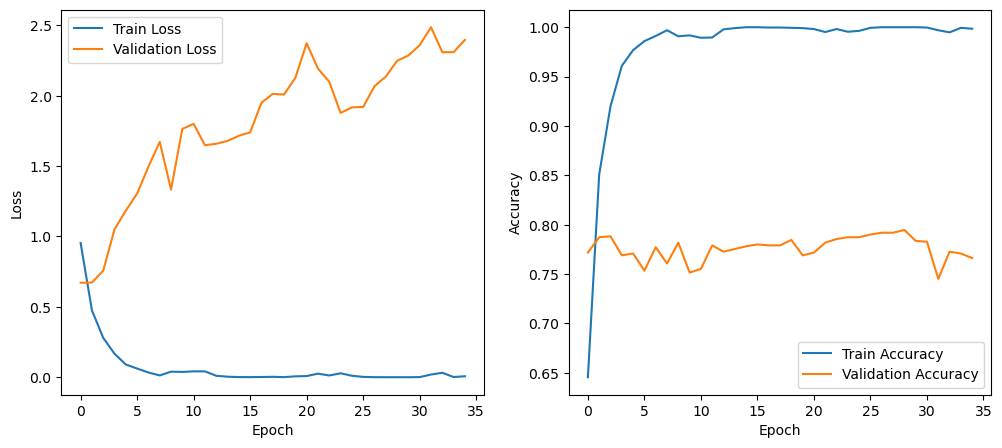

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
model.eval()
total_accurate = 0
test_loss = 0

all_predicted_labels = []
all_true_labels = []

for batch in test_dataloader:
    # Pindahkan batch ke preferensi device
    batch = tuple(t.to(device) for t in batch)
    input_ids, attention_mask, labels = batch

    # Ambil prediction output
    outputs = model(input_ids.to(device), attention_mask=attention_mask.to(device))
    logits = outputs.logits # Ambil dalam bentuk logits

    # Cast logits ke float data type
    logits = logits.float()

    # Kalkulasi loss (kita juga memastikan label dalam bentuk long data type)
    loss = F.cross_entropy(logits, labels.long())
    test_loss += loss.item() # Tambahkan akumulasi loss ke total loss

    # Kalkulasi performance
    _, predicted_labels = torch.max(logits, dim=1) # Hitung prediksi paling mungkin menggunakan argmax
    correct_predictions = torch.sum(predicted_labels == labels) # Hitung jumlah prediksi yang benar
    total_accurate += correct_predictions.item() # Tambahkan akumulasi prediksi yang benar

    # Tambahkan predicted and true labels untuk confusion matrix calculation
    all_predicted_labels.extend(predicted_labels.cpu().numpy())
    all_true_labels.extend(labels.cpu().numpy())

avg_val_loss = test_loss / len(test_dataloader) # Hitung rata-rata validation loss
avg_accuracy = total_accurate / len(test_data) # Hitung rata-rata validation accuracy
print(f'Testing Loss: {avg_val_loss}, Testing Accuracy: {avg_accuracy}')

# Kalkulasi confusion matrix
conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels) # Membuat confusion matrix dalam bentuk sederhana
print("Confusion Matrix:")
print(conf_matrix)

Testing Loss: 2.590425690015157, Testing Accuracy: 0.7607699358386801
Confusion Matrix:
[[171  10   7  13  19]
 [ 23 133  27   6  14]
 [  8   9 190   6  13]
 [ 16   2   8 167  14]
 [ 39   7   8  12 169]]


Code dibawah ini akan menghasikan plottingan confusion matrix dari model untuk menampilkan seberapa bagus model melakukan klassifikasi dengan melihat True Positive, False Positive, False Negative, dan True Negative. Dapat dilihat bahwa model berhasil mengklasifikasi dengan nilai rata 170 untuk label 0, 3 dan 4 sedangkan label 2 memiliki nilai tertinggi dengan nilai 190 dan 3 memiliki nilai terendah dengan nilai 133.

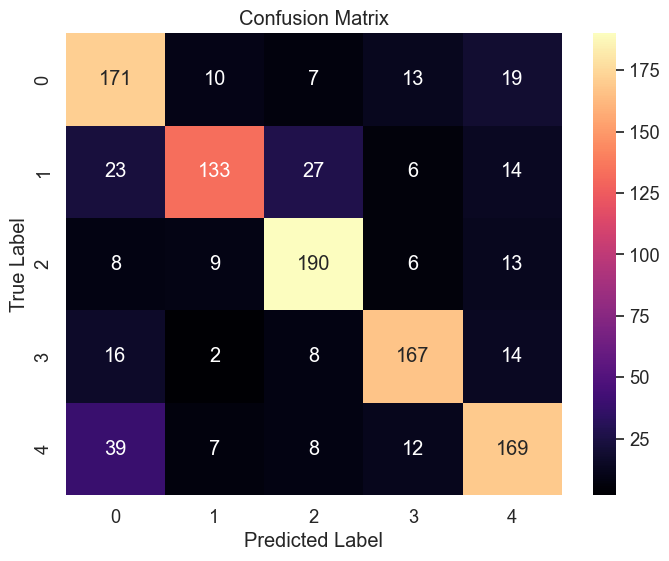

In [ ]:
# Plot confusion matrix menggunakan heatmap
# Disini kami menggunakan library seaborn untuk mendisplay plot confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, cmap='magma', fmt='g', xticklabels=True, yticklabels=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Code dibawah ini akan melakukan perhitungan hasil accuracy, recall, F1, dan keseluruhan laporan dari analisa antara label asli dan label prediksi menggunakan library dari scikit-learn.

In [ ]:
# Kalkulasi nilai precision, recall, and F1 score serta tampilkan laporan keseluruhan
precision = precision_score(all_true_labels, all_predicted_labels, average='weighted')
recall = recall_score(all_true_labels, all_predicted_labels, average='weighted')
f1 = f1_score(all_true_labels, all_predicted_labels, average='weighted')
report = classification_report(all_true_labels, all_predicted_labels)

# Print evaluation metrics
print(f'Accuracy: {avg_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'Report: {report}')

Accuracy: 0.7607699358386801
Precision: 0.7661571693391133
Recall: 0.7607699358386801
F1 Score: 0.7605666098314352
Report:               precision    recall  f1-score   support

           0       0.67      0.78      0.72       220
           1       0.83      0.66      0.73       203
           2       0.79      0.84      0.82       226
           3       0.82      0.81      0.81       207
           4       0.74      0.72      0.73       235

    accuracy                           0.76      1091
   macro avg       0.77      0.76      0.76      1091
weighted avg       0.77      0.76      0.76      1091



Code dibawah ini melakukan encoding dari label dataset menggunakan library scikit-learn.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Ambil label dataset untuk proses encoding
topic_labels = dataset['label']

# Instantiate the label encoder
label_encoder = LabelEncoder()

# Fit the label encoder to the encoded emotion labels
label_encoder.fit(topic_labels)

LabelEncoder()

In [ ]:
# def encoding(num):
#   if num == 1: return 'social'
#   elif num == 2: return 'education'
#   elif num == 3: return 'health'
#   elif num == 4: return 'career'
#   else: return 'hobby'

Code dibawah ini melakukan prediksi dari data baru atau input.

In [ ]:
def predict_topic(text, label_encoder):
    # Tokenize text dengan tokenizer yang sama dipakai saat training
    inputs = tokenizer.encode_plus(text, add_special_tokens=True, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)  # Move input to the same device as the model
    attention_mask = inputs['attention_mask'].to(device)  # Move attention mask to the same device as the model

    # Buat prediksi
    with torch.no_grad():
        model.eval()  # Set model ke evaluation mode
        outputs = model(input_ids, attention_mask=attention_mask)
    logits = outputs.logits

    # Ambil predicted label
    predicted_label = torch.argmax(logits, dim=1).item()

    # Decode predicted label menggunakan label_encoder
    predicted_topic = label_encoder.inverse_transform([predicted_label])[0]

    return predicted_topic, logits
    # return encoding(predicted_topic), logits

# Contoh penggunaan
text = "I'm going to have dinner outside this afternoon"
predicted_topic, predicted_label = predict_topic(text, label_encoder)
print(f'Predicted Topic: {predicted_topic}')
print(f'Predicted Label: {predicted_label}')

Predicted Topic: social
Predicted Label: tensor([[-0.2962, -1.5574, -2.1179, -1.1537,  4.7732]], device='cuda:0')


Code dibawah ini digunakan untuk menyimpan model yang sudah dilatih ke dalam file last_trained_model_checkpoint_1.0.pth

In [ ]:
# Save the last trained model
# Checkpoint ini sendiri akan menyimpan model_state_dict
checkpoint = {
    'model_state_dict': model.state_dict()
}

torch.save(checkpoint, 'last_trained_model_checkpoint_1.0.pth')